In [ ]:
import os

files = os.listdir('/content')

for file in files:
    if file.endswith('.csv'):
        print(file)


olist_order_items_dataset.csv
olist_products_dataset.csv
product_category_name_translation.csv
olist_sellers_dataset.csv
olist_order_reviews_dataset.csv
olist_customers_dataset.csv
olist_orders_dataset.csv
olist_geolocation_dataset.csv
olist_order_payments_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv('/content/olist_customers_dataset.csv')
geolocation = pd.read_csv('/content/olist_geolocation_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
orders = pd.read_csv('/content/olist_orders_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist_sellers_dataset.csv')
translation = pd.read_csv('/content/product_category_name_translation.csv')

print("All datasets loaded successfully!")


All datasets loaded successfully!


In [ ]:
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Customers: 99,441 rows × 5 columns
Geolocation: 1,000,163 rows × 5 columns
Order Items: 112,650 rows × 7 columns
Order Payments: 103,886 rows × 5 columns
Order Reviews: 99,224 rows × 7 columns
Orders: 99,441 rows × 8 columns
Products: 32,951 rows × 9 columns
Sellers: 3,095 rows × 4 columns
Category Translation: 71 rows × 2 columns


In [ ]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(df.columns.tolist())


Customers
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Geolocation
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Order Items
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Order Payments
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Order Reviews
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Orders
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Products
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_heigh

In [ ]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)
    print(df.isnull().sum())


Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Geolocation
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Order Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Order Reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Orders
order_id

In [ ]:
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Orders": orders,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Customers: 99,441 rows × 5 columns
Geolocation: 1,000,163 rows × 5 columns
Order Items: 112,650 rows × 7 columns
Order Payments: 103,886 rows × 5 columns
Order Reviews: 99,224 rows × 7 columns
Orders: 99,441 rows × 8 columns
Products: 32,951 rows × 9 columns
Sellers: 3,095 rows × 4 columns
Category Translation: 71 rows × 2 columns


In [ ]:
print("ORDERS")
print(orders.head())

print("\nCUSTOMERS")
print(customers.head())

print("\nORDER ITEMS")
print(order_items.head())

print("\nPRODUCTS")
print(products.head())

print("\nREVIEWS")
print(order_reviews.head())

print("\nPAYMENTS")
print(order_payments.head())

ORDERS
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           

In [ ]:
print("Orders columns:")
print(orders.columns.tolist())

print("\nCustomers columns:")
print(customers.columns.tolist())

print("\nOrder Items columns:")
print(order_items.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nReviews columns:")
print(order_reviews.columns.tolist())

print("\nPayments columns:")
print(order_payments.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Customers columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Order Items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Products columns:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Reviews columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Payments columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [ ]:
print("Unique orders:", orders['order_id'].nunique())
print("Unique customers:", customers['customer_id'].nunique())
print("Unique products:", products['product_id'].nunique())

Unique orders: 99441
Unique customers: 99441
Unique products: 32951


In [ ]:
print(
    "Orders in order_items:",
    order_items['order_id'].nunique()
)

print(
    "Orders in reviews:",
    order_reviews['order_id'].nunique()
)

print(
    "Orders in payments:",
    order_payments['order_id'].nunique()
)

Orders in order_items: 98666
Orders in reviews: 98673
Orders in payments: 99440


In [ ]:
# Make copies so the original raw datasets remain unchanged
orders_clean = orders.copy()
customers_clean = customers.copy()
items_clean = order_items.copy()
products_clean = products.copy()
reviews_clean = order_reviews.copy()
payments_clean = order_payments.copy()
translation_clean = translation.copy()

# ---------------------------------------------------
# 1. Convert date columns to datetime
# ---------------------------------------------------

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors='coerce')

items_clean['shipping_limit_date'] = pd.to_datetime(
    items_clean['shipping_limit_date'],
    errors='coerce'
)

# ---------------------------------------------------
# 2. Remove exact duplicate records
# ---------------------------------------------------

orders_clean = orders_clean.drop_duplicates()
customers_clean = customers_clean.drop_duplicates()
items_clean = items_clean.drop_duplicates()
products_clean = products_clean.drop_duplicates()
reviews_clean = reviews_clean.drop_duplicates()
payments_clean = payments_clean.drop_duplicates()
translation_clean = translation_clean.drop_duplicates()

# ---------------------------------------------------
# 3. Translate product categories into English
# ---------------------------------------------------

products_clean = products_clean.merge(
    translation_clean,
    on='product_category_name',
    how='left'
)

# Use English category where available
products_clean['product_category'] = products_clean[
    'product_category_name_english'
].fillna(
    products_clean['product_category_name']
)

# Replace missing category with "Unknown"
products_clean['product_category'] = products_clean[
    'product_category'
].fillna('Unknown')

# ---------------------------------------------------
# 4. Aggregate order items to ORDER level
# ---------------------------------------------------

item_summary = items_clean.groupby('order_id').agg(
    total_items=('order_item_id', 'count'),
    total_product_value=('price', 'sum'),
    total_freight_value=('freight_value', 'sum'),
    unique_products=('product_id', 'nunique')
).reset_index()

# ---------------------------------------------------
# 5. Aggregate payments to ORDER level
# ---------------------------------------------------

payment_summary = payments_clean.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max')
).reset_index()

# Most common payment type for each order
payment_type = (
    payments_clean
    .groupby('order_id')['payment_type']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown')
    .reset_index()
)

payment_summary = payment_summary.merge(
    payment_type,
    on='order_id',
    how='left'
)

# ---------------------------------------------------
# 6. Aggregate reviews to ORDER level
# ---------------------------------------------------

review_summary = reviews_clean.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

# ---------------------------------------------------
# 7. Merge orders + customers
# ---------------------------------------------------

master_df = orders_clean.merge(
    customers_clean[
        ['customer_id', 'customer_unique_id',
         'customer_city', 'customer_state']
    ],
    on='customer_id',
    how='left'
)

# ---------------------------------------------------
# 8. Merge order-level item summary
# ---------------------------------------------------

master_df = master_df.merge(
    item_summary,
    on='order_id',
    how='left'
)

# ---------------------------------------------------
# 9. Merge payment summary
# ---------------------------------------------------

master_df = master_df.merge(
    payment_summary,
    on='order_id',
    how='left'
)

# ---------------------------------------------------
# 10. Merge review summary
# ---------------------------------------------------

master_df = master_df.merge(
    review_summary,
    on='order_id',
    how='left'
)

# ---------------------------------------------------
# 11. Create calculated delivery fields
# ---------------------------------------------------

master_df['delivery_days'] = (
    master_df['order_delivered_customer_date']
    - master_df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

master_df['estimated_delivery_days'] = (
    master_df['order_estimated_delivery_date']
    - master_df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

master_df['delivery_delay_days'] = (
    master_df['order_delivered_customer_date']
    - master_df['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

# ---------------------------------------------------
# 12. Delivery status
# ---------------------------------------------------

master_df['delivery_status'] = np.where(
    master_df['delivery_delay_days'].isna(),
    'Not Delivered',
    np.where(
        master_df['delivery_delay_days'] > 0,
        'Late',
        'On Time'
    )
)

# ---------------------------------------------------
# 13. Create revenue field
# ---------------------------------------------------

master_df['revenue'] = master_df['total_product_value']

# ---------------------------------------------------
# 14. Create month/year fields
# ---------------------------------------------------

master_df['order_month'] = (
    master_df['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

master_df['order_year'] = (
    master_df['order_purchase_timestamp']
    .dt.year
)

# ---------------------------------------------------
# Final dataset
# ---------------------------------------------------

print("Master dataset created successfully!")
print("Rows:", len(master_df))
print("Columns:", len(master_df.columns))

master_df.head()

Master dataset created successfully!
Rows: 99441
Columns: 26


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,payment_installments,payment_type,review_score,delivery_days,estimated_delivery_days,delivery_delay_days,delivery_status,revenue,order_month,order_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,1.0,voucher,4.0,8.436574,15.544063,-7.107488,On Time,29.99,2017-10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,1.0,boleto,4.0,13.782037,19.137766,-5.355729,On Time,118.70,2018-07,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,3.0,credit_card,5.0,9.394213,26.639711,-17.245498,On Time,159.90,2018-08,2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,1.0,credit_card,5.0,13.208750,26.188819,-12.980069,On Time,45.00,2017-11,2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,1.0,credit_card,5.0,2.873877,12.112049,-9.238171,On Time,19.90,2018-02,2018


In [ ]:
print(master_df.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
customer_city                       0
customer_state                      0
total_items                       775
total_product_value               775
total_freight_value               775
unique_products                   775
total_payment_value                 1
payment_installments                1
payment_type                        1
review_score                      768
delivery_days                    2965
estimated_delivery_days             0
delivery_delay_days              2965
delivery_status                     0
revenue                           775
order_month                         0
order_year                          0
dtype: int64

In [ ]:
print(master_df[
    ['revenue',
     'total_payment_value',
     'review_score',
     'delivery_days',
     'delivery_delay_days']
].describe())

            revenue  total_payment_value  review_score  delivery_days  \
count  98666.000000         99440.000000  98673.000000   96476.000000   
mean     137.754076           160.990267      4.086793      12.558702   
std      210.645145           221.951257      1.346274       9.546530   
min        0.850000             0.000000      1.000000       0.533414   
25%       45.900000            62.010000      4.000000       6.766403   
50%       86.900000           105.290000      5.000000      10.217755   
75%      149.900000           176.970000      5.000000      15.720327   
max    13440.000000         13664.080000      5.000000     209.628611   

       delivery_delay_days  
count         96476.000000  
mean            -11.179120  
std              10.186113  
min            -146.016123  
25%             -16.244384  
50%             -11.948941  
75%              -6.390000  
max             188.975081  


In [ ]:
print(master_df['delivery_status'].value_counts())

delivery_status
On Time          88649
Late              7827
Not Delivered     2965
Name: count, dtype: int64


In [ ]:
print(master_df['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [ ]:
print("Duplicate rows:", master_df.duplicated().sum())
print("Duplicate order IDs:", master_df['order_id'].duplicated().sum())
print("Negative delivery days:",
      (master_df['delivery_days'] < 0).sum())

print("Very long deliveries (>60 days):",
      (master_df['delivery_days'] > 60).sum())

print("Very large delays (>60 days):",
      (master_df['delivery_delay_days'] > 60).sum())
print(master_df.groupby('order_status')['revenue'].agg(['count', 'sum', 'mean']))

Duplicate rows: 0
Duplicate order IDs: 0
Negative delivery days: 0
Very long deliveries (>60 days): 306
Very large delays (>60 days): 84
              count          sum        mean
order_status                                
approved          2       209.60  104.800000
canceled        461     95235.27  206.584100
created           0         0.00         NaN
delivered     96478  13221498.11  137.041586
invoiced        312     61526.37  197.199904
processing      301     60439.22  200.794751
shipped        1106    150727.44  136.281591
unavailable       6      2007.69  334.615000


                       total_sales  total_items  unique_orders  avg_item_price
product_category                                                              
health_beauty           1258681.34         9670           8836      130.163531
watches_gifts           1205005.68         5991           5624      201.135984
bed_bath_table          1036988.68        11115           9417       93.296327
sports_leisure           988048.97         8641           7720      114.344285
computers_accessories    911954.32         7827           6689      116.513903
furniture_decor          729762.49         8334           6449       87.564494
cool_stuff               635290.85         3796           3632      167.357969
housewares               632248.66         6964           5884       90.788148
auto                     592720.11         4235           3897      139.957523
garden_tools             485256.46         4347           3518      111.630196
toys                     483946.60         4117     

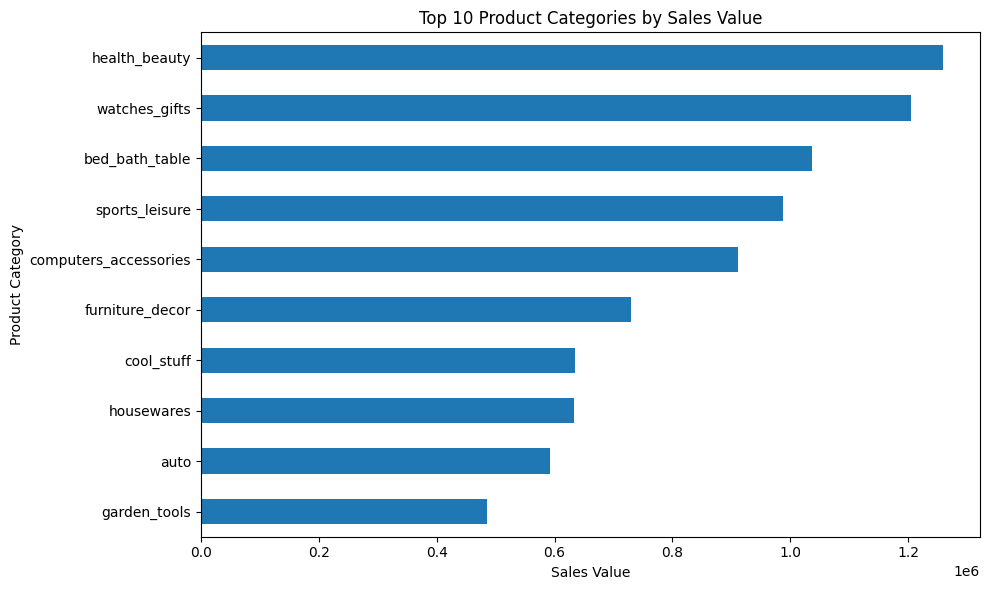

In [ ]:
# Create category-level analysis dataset

category_items = items_clean.merge(
    products_clean[['product_id', 'product_category']],
    on='product_id',
    how='left'
)

category_items['product_category'] = category_items['product_category'].fillna('Unknown')

category_analysis = category_items.groupby('product_category').agg(
    total_sales=('price', 'sum'),
    total_items=('order_item_id', 'count'),
    unique_orders=('order_id', 'nunique'),
    avg_item_price=('price', 'mean')
).sort_values('total_sales', ascending=False)

print(category_analysis.head(15))
category_analysis['sales_share_%'] = (
    category_analysis['total_sales'] /
    category_analysis['total_sales'].sum()
) * 100

print(category_analysis.head(15))
category_analysis.head(10)['total_sales'].sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Top 10 Product Categories by Sales Value')
plt.xlabel('Sales Value')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [ ]:
category_analysis['sales_share_%'] = (
    category_analysis['total_sales'] /
    category_analysis['total_sales'].sum()
) * 100

category_analysis['cumulative_share_%'] = (
    category_analysis['sales_share_%'].cumsum()
)

print(
    category_analysis[
        ['total_sales', 'sales_share_%', 'cumulative_share_%']
    ].head(10)
)

                       total_sales  sales_share_%  cumulative_share_%
product_category                                                     
health_beauty           1258681.34       9.260700            9.260700
watches_gifts           1205005.68       8.865783           18.126483
bed_bath_table          1036988.68       7.629605           25.756088
sports_leisure           988048.97       7.269533           33.025621
computers_accessories    911954.32       6.709669           39.735290
furniture_decor          729762.49       5.369200           45.104489
cool_stuff               635290.85       4.674128           49.778618
housewares               632248.66       4.651745           54.430363
auto                     592720.11       4.360916           58.791278
garden_tools             485256.46       3.570256           62.361534


                 orders  avg_review_score  avg_delivery_days  avg_delay_days
delivery_status                                                             
Late               7827          2.566562          31.518708        9.552206
On Time           88649          4.294151          10.884685      -13.009531
Late delivery percentage: 8.11%


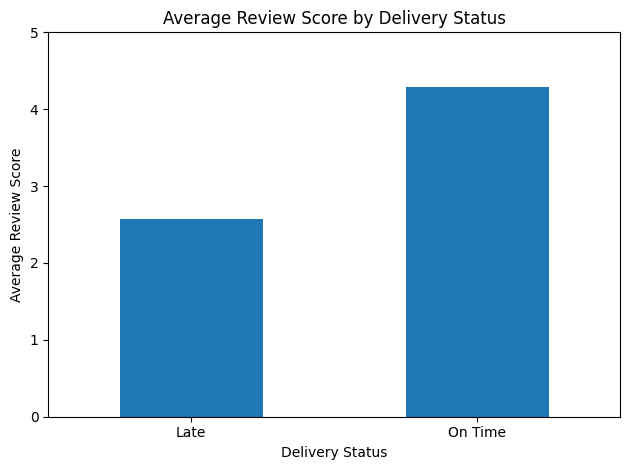

In [ ]:
delivery_review = master_df[
    master_df['delivery_status'].isin(['On Time', 'Late'])
].groupby('delivery_status').agg(
    orders=('order_id', 'count'),
    avg_review_score=('review_score', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delivery_delay_days', 'mean')
)

print(delivery_review)
delivered_orders = master_df[
    master_df['delivery_status'].isin(['On Time', 'Late'])
]

late_percentage = (
    (delivered_orders['delivery_status'] == 'Late').sum()
    / len(delivered_orders)
) * 100

print(f"Late delivery percentage: {late_percentage:.2f}%")
delivery_review['avg_review_score'].plot(kind='bar')

plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

                orders  sales_value  avg_order_value
customer_state                                      
SP               41746   5202955.05       125.751179
RJ               12852   1824092.67       142.931568
MG               11635   1585308.03       137.327445
RS                5466    750304.02       138.126661
PR                5045    683083.76       136.671421
SC                3637    520553.34       144.117757
BA                3380    511349.99       152.278139
DF                2140    302603.94       142.401854
ES                2033    275037.31       135.820894
GO                2020    294591.95       146.782237


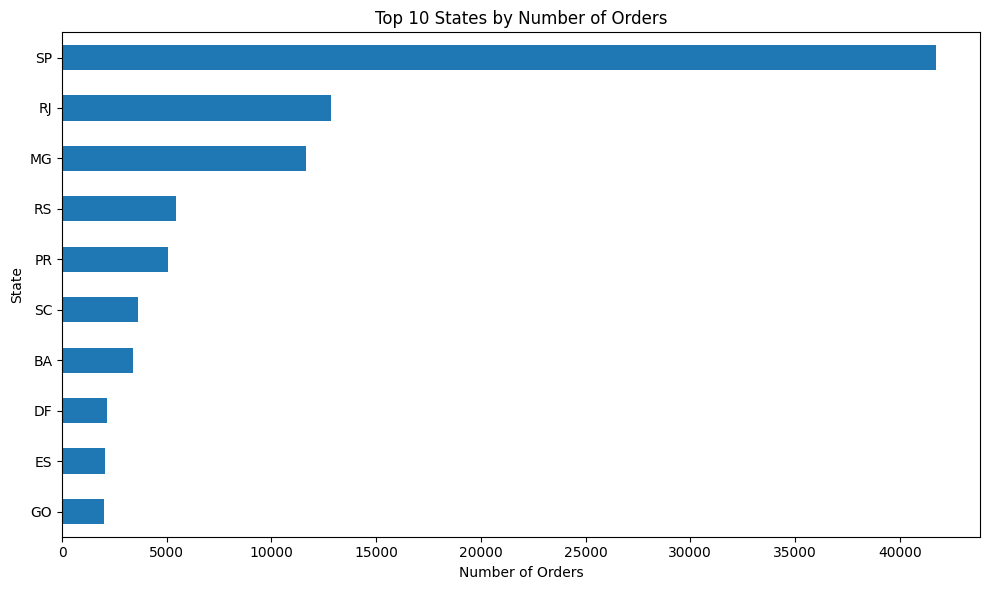

In [ ]:
state_analysis = master_df.groupby('customer_state').agg(
    orders=('order_id', 'count'),
    sales_value=('revenue', 'sum'),
    avg_order_value=('revenue', 'mean')
).sort_values('orders', ascending=False)

print(state_analysis.head(10))
state_analysis.head(10)['orders'].sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Top 10 States by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('State')
plt.tight_layout()
plt.show()

             orders  sales_value  avg_order_value
order_month                                      
2016-09           4       267.36        89.120000
2016-10         324     49507.66       160.739156
2016-12           1        10.90        10.900000
2017-01         800    120312.87       152.487795
2017-02        1780    247303.02       142.702262
2017-03        2682    374344.30       141.743393
2017-04        2404    359927.23       150.534182
2017-05        3700    506071.14       138.270803
2017-06        3245    433038.60       134.609450
2017-07        4026    498031.48       125.480343
2017-08        4331    573971.68       133.699436
2017-09        4285    624401.69       147.160427
2017-10        4631    664219.43       145.407056
2017-11        7544   1010271.37       135.588695
2017-12        5673    743914.17       132.274924
2018-01        7269    950030.36       131.583152
2018-02        6728    844178.71       126.109756
2018-03        7211    983213.44       136.785398


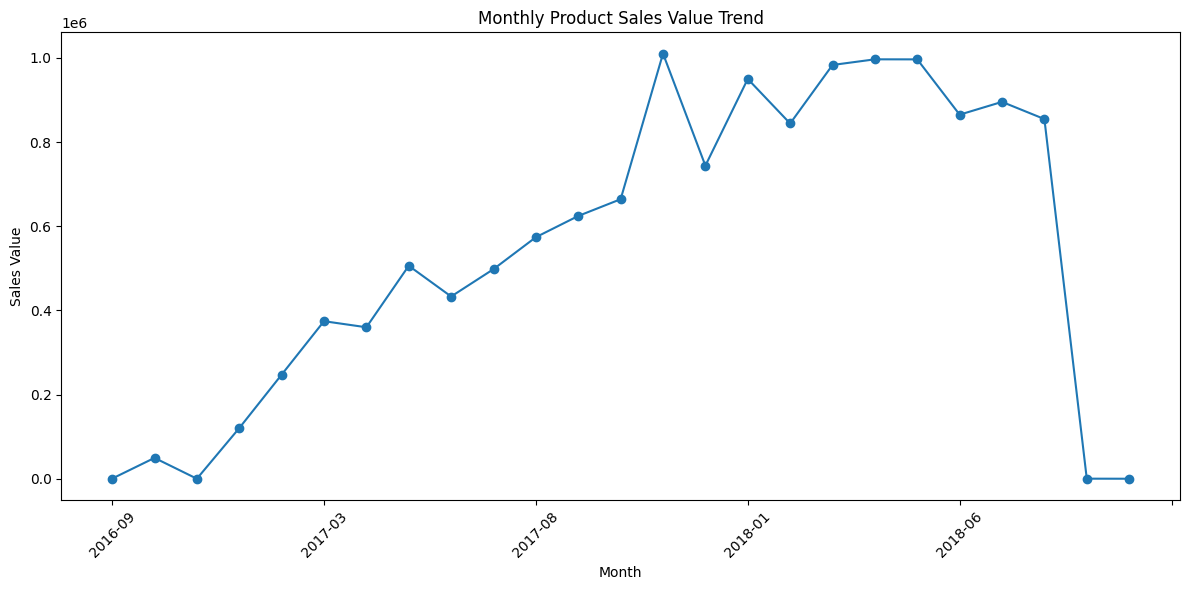

In [ ]:
monthly_analysis = master_df.groupby('order_month').agg(
    orders=('order_id', 'count'),
    sales_value=('revenue', 'sum'),
    avg_order_value=('revenue', 'mean')
)

print(monthly_analysis)
monthly_analysis['sales_value'].plot(
    kind='line',
    figsize=(12, 6),
    marker='o'
)

plt.title('Monthly Product Sales Value Trend')
plt.xlabel('Month')
plt.ylabel('Sales Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Compare review scores by delivery status
surprise_analysis = master_df[
    master_df['delivery_status'].isin(['On Time', 'Late'])
].groupby('delivery_status').agg(
    orders=('order_id', 'count'),
    avg_review=('review_score', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delivery_delay_days', 'mean')
)

print(surprise_analysis)
# Create order-category dataset
category_reviews = category_items[
    ['order_id', 'product_category']
].drop_duplicates()

category_reviews = category_reviews.merge(
    master_df[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

category_review_analysis = category_reviews.groupby('product_category').agg(
    orders=('order_id', 'count'),
    avg_review=('review_score', 'mean')
)

# Only consider categories with at least 100 reviewed orders
category_review_analysis = category_review_analysis[
    category_review_analysis['orders'] >= 100
].sort_values('avg_review')

print(category_review_analysis.head(10))

                 orders  avg_review  avg_delivery_days  avg_delay_days
delivery_status                                                       
Late               7827    2.566562          31.518708        9.552206
On Time           88649    4.294151          10.884685      -13.009531
                           orders  avg_review
product_category                             
office_furniture             1273    3.616390
fashion_male_clothing         112    3.702703
audio                         350    3.834294
construction_tools_safety     167    3.849398
home_confort                  397    3.863291
fixed_telephony               217    3.901869
Unknown                      1451    3.912787
fashion_underwear_beach       121    3.933333
home_construction             490    3.967146
bed_bath_table               9417    3.970740


In [ ]:
missing_revenue = master_df[master_df['revenue'].isna()]

print(missing_revenue['order_status'].value_counts())

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


In [ ]:
print(
    master_df.groupby('order_status')['revenue']
    .apply(lambda x: x.isna().sum())
)

order_status
approved         0
canceled       164
created          5
delivered        0
invoiced         2
processing       0
shipped          1
unavailable    603
Name: revenue, dtype: int64


In [ ]:
# 1. Main order-level data
dashboard_orders = master_df.copy()

# 2. Category-level analysis
dashboard_category = (
    category_items.groupby('product_category')
    .agg(
        total_sales=('price', 'sum'),
        total_items=('product_id', 'count'),
        unique_orders=('order_id', 'nunique')
    )
    .reset_index()
    .sort_values('total_sales', ascending=False)
)

# 3. State-level analysis
dashboard_state = (
    master_df.groupby('customer_state')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_sales=('revenue', 'sum'),
        avg_order_value=('revenue', 'mean')
    )
    .reset_index()
    .sort_values('total_orders', ascending=False)
)

# 4. Monthly analysis
dashboard_monthly = (
    master_df.groupby('order_month')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_sales=('revenue', 'sum')
    )
    .reset_index()
    .sort_values('order_month')
)

# 5. Delivery vs review
dashboard_delivery = (
    master_df[master_df['review_score'].notna()]
    .groupby('delivery_status')
    .agg(
        total_orders=('order_id', 'nunique'),
        avg_review_score=('review_score', 'mean'),
        avg_delivery_days=('delivery_days', 'mean')
    )
    .reset_index()
)

print("Orders:", dashboard_orders.shape)
print("Categories:", dashboard_category.shape)
print("States:", dashboard_state.shape)
print("Monthly:", dashboard_monthly.shape)
print("Delivery:", dashboard_delivery.shape)

Orders: (99441, 26)
Categories: (74, 4)
States: (27, 4)
Monthly: (25, 3)
Delivery: (3, 4)


In [ ]:
dashboard_orders.to_csv('dashboard_orders.csv', index=False)
dashboard_category.to_csv('dashboard_category.csv', index=False)
dashboard_state.to_csv('dashboard_state.csv', index=False)
dashboard_monthly.to_csv('dashboard_monthly.csv', index=False)
dashboard_delivery.to_csv('dashboard_delivery.csv', index=False)

print("All dashboard files created successfully.")

All dashboard files created successfully.


In [ ]:
import os

print(os.listdir())


['.config', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv', 'dashboard_monthly.csv', 'olist_sellers_dataset.csv', 'dashboard_orders.csv', 'dashboard_category.csv', 'olist_order_reviews_dataset.csv', 'olist_customers_dataset.csv', 'dashboard_delivery.csv', 'olist_orders_dataset.csv', 'olist_geolocation_dataset.csv', 'dashboard_state.csv', 'olist_order_payments_dataset.csv', 'sample_data']


In [ ]:
from google.colab import files

files.download('dashboard_orders.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('dashboard_category.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('dashboard_state.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('dashboard_monthly.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('dashboard_delivery.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>